# 03 - Acoustic PINN Forward (Known Vp)
Train `AcousticPINN` with fixed true velocity as a forward sanity test before inversion.

In [1]:
from pathlib import Path
import sys
import numpy as np

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'src').exists() else NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.io import load_yaml, seed_everything, get_device, resolve_path
from src.data import load_marmousi_vp
from src.forward import AcquisitionGeometry
from src.pinn.acoustic_pinn import AcousticPINN, AcousticPINNConfig
from src.inversion.trainer import AcousticPINNFWITrainer
from src.utils.viz import plot_losses

CONFIG_FILE = 'fastdev.yaml'  # quick forward sanity test
cfg = load_yaml(PROJECT_ROOT / 'configs' / CONFIG_FILE)
seed_everything(int(cfg['seed']))
device = get_device(cfg.get('device', 'auto'))
print('Device:', device)

Device: cuda


In [2]:
vp_true = load_marmousi_vp(resolve_path(PROJECT_ROOT, cfg['data']['vp_path']), subsample=int(cfg['model']['subsample']))
geom = AcquisitionGeometry.from_npz(PROJECT_ROOT / cfg['data']['geometry_path'])
observed = np.load(PROJECT_ROOT / cfg['data']['observed_path']).astype(np.float32)
print('Vp shape:', vp_true.shape, '| Observed shape:', observed.shape)

Vp shape: (176, 681) | Observed shape: (8, 1000, 169)


PINN-FWI:   0%|          | 2/1000 [00:00<05:45,  2.89it/s, data=2.898e-02, fmax=2.0, mode=P-, pde=1.454e-01, total=8.708e-02]

[WEIGHTED] epoch=0 data=1.488e-01 pde=9.056e-03 bc=4.562e-06 ic=0.000e+00 reg=1.271e-04


PINN-FWI:   1%|          | 12/1000 [00:01<01:53,  8.68it/s, data=1.088e-01, fmax=2.3, mode=P-, pde=6.622e-02, total=3.203e-01]

[WEIGHTED] epoch=10 data=1.064e-01 pde=1.238e-01 bc=5.906e-06 ic=0.000e+00 reg=1.271e-04


PINN-FWI:   2%|▏         | 21/1000 [00:02<01:49,  8.93it/s, data=2.343e-01, fmax=2.5, mode=P-, pde=1.451e-02, total=1.993e-01]

...

PINN-FWI:  99%|█████████▉| 992/1000 [01:58<00:00,  8.89it/s, data=5.011e-01, fmax=10.0, mode=P-, pde=1.043e-02, total=1.503e+01]

[WEIGHTED] epoch=990 data=3.083e+01 pde=9.285e-02 bc=3.709e-07 ic=0.000e+00 reg=1.271e-04


PINN-FWI: 100%|█████████▉| 999/1000 [01:59<00:00,  8.82it/s, data=4.324e-01, fmax=10.0, mode=P-, pde=9.640e-03, total=1.309e+01]

[Epoch 01000] L=1.3089e+01, L_data=4.3243e-01, L_pde=9.6403e-03, L_reg=2.5427e-01


PINN-FWI: 100%|██████████| 1000/1000 [01:59<00:00,  8.37it/s, data=4.324e-01, fmax=10.0, mode=P-, pde=9.640e-03, total=1.309e+01]


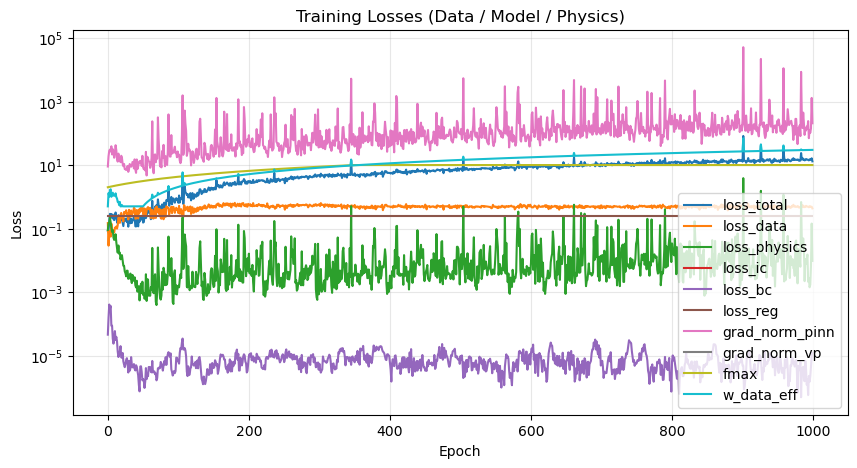

In [3]:
pinn_cfg = AcousticPINNConfig(
    hidden_layers=int(cfg['pinn']['hidden_layers']),
    hidden_width=int(cfg['pinn']['hidden_width']),
    activation=str(cfg['pinn']['activation']),
    fourier_features=bool(cfg['pinn']['fourier_features']),
    n_fourier=int(cfg['pinn']['n_fourier']),
    fourier_scale=float(cfg['pinn']['fourier_scale']),
)
pinn = AcousticPINN(pinn_cfg).to(device)

trainer = AcousticPINNFWITrainer(
    pinn=pinn,
    velocity_net=None,
    observed=observed,
    geometry=geom,
    vp_true=vp_true,
    config=cfg,
    project_root=PROJECT_ROOT,
    invert_vp=False,
)
history = trainer.train()
plot_losses(history)